In [1]:
from pathlib import Path
import sys
import joblib

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.preprocessing import preprocess_features

MODELS_DIR = PROJECT_ROOT / "models"

model = joblib.load(MODELS_DIR / "xgb_model.joblib")
threshold = joblib.load(MODELS_DIR / "decision_threshold.joblib")
feature_cols = joblib.load(MODELS_DIR / "feature_columns.joblib")

print(type(model))
print("Threshold:", threshold)
print("Features:", feature_cols)

<class 'xgboost.sklearn.XGBClassifier'>
Threshold: 0.15371445
Features: ['Air temperature', 'Process temperature', 'Rotational speed', 'Torque', 'Tool wear', 'type_L', 'type_M', 'power_w', 'temp_diff_k', 'wear_torque_interaction']


In [2]:
DATA_DIR = PROJECT_ROOT / "data" / "raw"

print("Raw data files:")
for p in DATA_DIR.iterdir():
    print("-", p.name)

Raw data files:
- ai4i2020_raw.csv


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split

raw_df = pd.read_csv(DATA_DIR / "ai4i2020_raw.csv")

model_columns = [
    "Type",
    "Air temperature",
    "Process temperature",
    "Rotational speed",
    "Torque",
    "Tool wear",
    "Machine failure"
]

df = raw_df[model_columns].copy()

print(df.shape)
print(df.columns.tolist())

(10000, 7)
['Type', 'Air temperature', 'Process temperature', 'Rotational speed', 'Torque', 'Tool wear', 'Machine failure']


In [4]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["Machine failure"]
)

train_part, val_part = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df["Machine failure"]
)

print("Train:", train_part.shape)
print("Validation:", val_part.shape)
print("Test:", test_df.shape)

Train: (6400, 7)
Validation: (1600, 7)
Test: (2000, 7)


In [5]:
X_val = preprocess_features(
    val_part.drop(columns=["Machine failure"])
)

X_val = X_val[feature_cols]

y_val = val_part["Machine failure"]

print(X_val.shape)
print(y_val.value_counts())

(1600, 10)
Machine failure
0    1546
1      54
Name: count, dtype: int64


In [6]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(model)

shap_values = explainer(X_val)

print(shap_values.shape)

c:\Users\PC\Development\python projects\predictive-maintenance-ai4i\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(1600, 10)


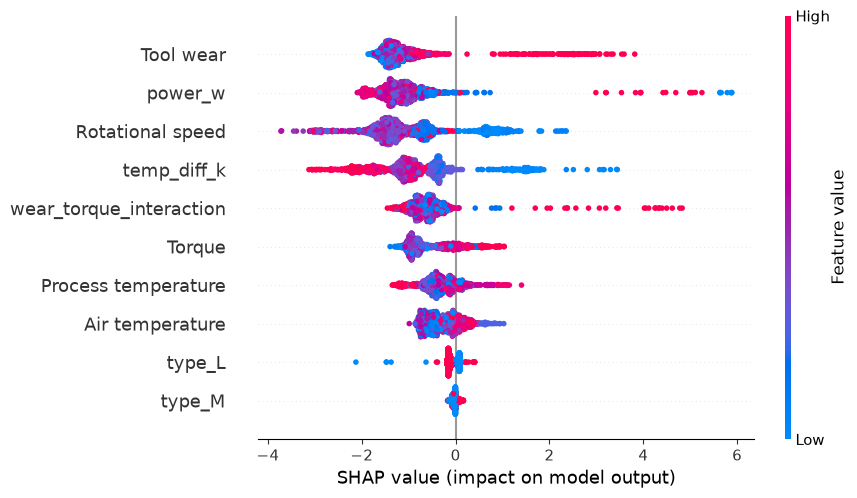

In [7]:
shap.plots.beeswarm(
    shap_values,
    max_display=10
)

plt.show()

### تفسير SHAP Summary Plot

يوضح هذا الرسم كيف ساهمت كل خاصية في دفع تنبؤ نموذج XGBoost نحو **العطل (`Machine failure = 1`)** أو نحو **الحالة السليمة (`Machine failure = 0`)** عبر بيانات الـValidation.

- كل نقطة تمثل سجلًا واحدًا.
- المحور الأفقي يمثل **قيمة SHAP**:
  - قيمة موجبة → الخاصية دفعت التنبؤ أكثر نحو العطل.
  - قيمة سالبة → الخاصية دفعت التنبؤ أكثر نحو الحالة السليمة.
  - قيمة قريبة من الصفر → تأثير ضعيف في ذلك السجل.
- اللون يمثل قيمة الخاصية نفسها:
  - الأحمر = قيمة مرتفعة.
  - الأزرق = قيمة منخفضة.
- الخصائص مرتبة من الأعلى إلى الأسفل حسب متوسط قوة تأثيرها في تنبؤات النموذج.

### أهم الملاحظات

- **Tool wear** هي أكثر خاصية تأثيرًا. القيم المرتفعة منها تدفع النموذج بوضوح نحو توقع العطل.
- **power_w** من أهم الخصائص أيضًا، لكن تأثيرها غير خطي؛ القيم المرتفعة أو المنخفضة لا ترتبط دائمًا باتجاه واحد، مما يدل على أن تأثيرها يعتمد على ظروف تشغيل أخرى.
- **Rotational speed** تظهر أن السرعات المنخفضة غالبًا تدفع التنبؤ نحو العطل، بينما السرعات الأعلى تميل أكثر نحو الحالة السليمة.
- **temp_diff_k** لها تأثير واضح؛ القيم المنخفضة للفرق بين حرارة العملية وحرارة الهواء تميل إلى دفع النموذج نحو العطل.
- **wear_torque_interaction** تؤكد فائدة خاصية التفاعل التي أنشأناها، حيث إن اجتماع تآكل مرتفع مع Torque مرتفع قد يدفع التنبؤ بقوة نحو العطل.
- **Torque** المرتفع يميل عمومًا إلى دفع النموذج نحو العطل، وهو ما يتفق مع نتائج الـEDA السابقة.
- **Process temperature** و**Air temperature** لهما تأثير أقل وأكثر اعتمادًا على السياق.
- **type_L** وخصوصًا **type_M** لهما تأثير محدود مقارنة بالخصائص التشغيلية والميكانيكية.

بشكل عام، يشير الرسم إلى أن النموذج يعتمد بدرجة كبيرة على **تآكل الأداة وظروف الحمل الميكانيكي**، كما أن الخصائص التي تم إنشاؤها في مرحلة Feature Engineering مثل `power_w` و`temp_diff_k` و`wear_torque_interaction` أصبحت فعليًا مؤثرة في قرارات النموذج.

> ملاحظة: SHAP يفسر ما تعلّمه النموذج من البيانات، لكنه لا يثبت وجود علاقة سببية حقيقية بين الخاصية والعطل.

In [8]:
val_scores = model.predict_proba(X_val)[:, 1]

failure_indices = X_val.index[
    val_scores >= threshold
]

print("Predicted failures:", len(failure_indices))
print("Example index:", failure_indices[0])

Predicted failures: 139
Example index: 3445


In [9]:
idx = failure_indices[0]

row_position = X_val.index.get_loc(idx)

print("Risk score:", val_scores[row_position])
print("True label:", y_val.loc[idx])

X_val.loc[[idx]]

Risk score: 0.4840804
True label: 0


,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,type_L,type_M,power_w,temp_diff_k,wear_torque_interaction
3445,301.6,310.6,1599,36.1,208,0,1,6044.832673,9.0,7508.8


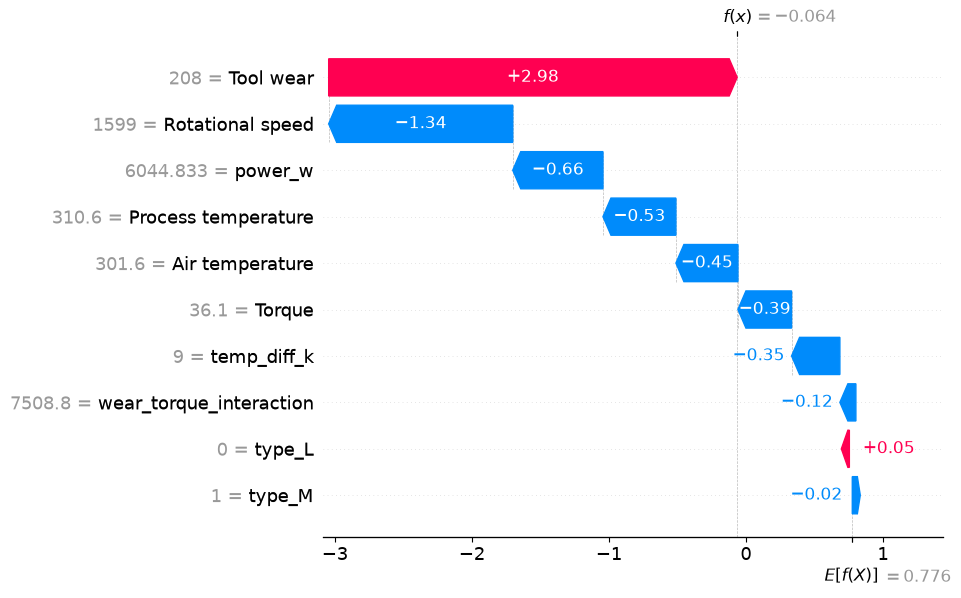

In [10]:
shap.plots.waterfall(
    shap_values[row_position],
    max_display=10
)

### تفسير SHAP Waterfall Plot

يوضح هذا الرسم سبب تصنيف النموذج لهذا السجل على أنه حالة عطل.

تبدأ عملية التفسير من القيمة المرجعية:

`E[f(X)] = 0.776`

وهي **Baseline output** للنموذج في SHAP، أي الخرج المتوقع الذي يبدأ منه التفسير قبل احتساب تأثير خصائص هذا السجل. هذه القيمة ليست احتمال عطل بنسبة 77.6%، بل هي خرج داخلي Raw output للنموذج.

بعد ذلك تضيف أو تطرح كل خاصية مساهمتها من هذه القيمة:

- اللون الأحمر يعني أن الخاصية دفعت النموذج أكثر نحو العطل.
- اللون الأزرق يعني أنها دفعت النموذج أكثر نحو الحالة السليمة.

في هذا السجل كان **Tool wear = 208** العامل الأقوى في اتجاه العطل، بقيمة SHAP تساوي تقريبًا `+2.98`.

في المقابل، عدة خصائص دفعت القرار في الاتجاه المعاكس، أهمها:

- `Rotational speed = 1599` → `-1.34`
- `power_w = 6044.8` → `-0.66`
- `Process temperature = 310.6` → `-0.53`
- `Air temperature = 301.6` → `-0.45`
- `Torque = 36.1` → `-0.39`
- `temp_diff_k = 9` → `-0.35`

بعد جمع جميع تأثيرات SHAP مع القيمة المرجعية، وصل خرج النموذج الخام إلى:

`f(x) = -0.064`

وهو ما يقابل Risk Score يقارب:

`0.484`

وبما أن:

`0.484 > 0.1537`

وهي عتبة القرار التي اخترناها، فقد صنف النموذج السجل على أنه **Failure**.

لكن القيمة الحقيقية لهذا السجل كانت:

`Machine failure = 0`

لذلك فإن هذه الحالة هي **False Positive**.

يوضح هذا المثال كيف يمكن لـSHAP أن يبين ليس فقط أن النموذج أخطأ، بل أيضًا لماذا اتجه نحو قرار العطل: كان ارتفاع `Tool wear` عاملًا قويًا جدًا، رغم أن معظم ظروف التشغيل الأخرى دفعت التنبؤ نحو الحالة السليمة.